# privateboost: Privacy-Preserving Federated XGBoost

This notebook demonstrates privateboost—a privacy-preserving XGBoost implementation using **Shamir secret sharing** with commitments.

**Contents:**
1. **Training** — End-to-end federated XGBoost on the Heart Disease dataset
2. **Split Quality Analysis** — How much accuracy do we lose from histogram binning?
3. **XGBoost Comparison** — Learning curves vs the XGBoost library
4. **Dropout Resilience** — How does training degrade when clients drop out?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import log_loss, accuracy_score

from privateboost import Client, ShareHolder, Aggregator

np.random.seed(42)

---
# Part 1: Training

**Scenario:** 297 patients want to collaboratively train a heart disease prediction model without revealing their individual health data.

**Protocol (2-of-3 Shamir threshold):**
1. Each patient (client) holds their own data
2. Clients create Shamir shares with commitments and send to shareholders
3. Aggregator collects commitments to find client overlap
4. Shareholders sum shares for valid commitments, send to aggregator
5. Aggregator reconstructs aggregates using Lagrange interpolation
6. Split decisions are broadcast back to clients

**Privacy guarantees:**
- Any single shareholder learns nothing (threshold = 2)
- Aggregator sees only aggregate statistics, never raw values
- Minimum 10 clients required to prevent individual isolation

## Load Data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv(url, names=columns, na_values="?")
df = df.dropna()
df["target"] = (df["target"] > 0).astype(int)

FEATURES = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

# Train/test split (80/20)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx]
df_test = df.iloc[split_idx:]

X_train = df_train[FEATURES].values.astype(float)
y_train = df_train["target"].values
X_test = df_test[FEATURES].values.astype(float)
y_test = df_test["target"].values

print(f"Train: {len(df_train)} patients, Test: {len(df_test)} patients")
print(f"Features: {len(FEATURES)}")

Train: 237 patients, Test: 60 patients
Features: 13


## Setup Protocol

In [3]:
# Hyperparameters
N_TREES = 15
MAX_DEPTH = 3
LEARNING_RATE = 0.15
LAMBDA_REG = 2.0
N_BINS = 10
N_SHAREHOLDERS = 3
THRESHOLD = 2  # 2-of-3 Shamir threshold
MIN_CLIENTS = 10  # Privacy threshold

# Create protocol actors
shareholders = [
    ShareHolder(party_id=i, x_coord=i + 1, min_clients=MIN_CLIENTS)
    for i in range(N_SHAREHOLDERS)
]
aggregator = Aggregator(
    shareholders,
    n_bins=N_BINS,
    threshold=THRESHOLD,
    min_clients=MIN_CLIENTS,
    learning_rate=LEARNING_RATE,
    lambda_reg=LAMBDA_REG,
)

# Each patient becomes a client
train_clients = [
    Client(
        client_id=f"patient_{i}",
        features=X_train[i],
        target=float(y_train[i]),
        shareholders=shareholders,
        threshold=THRESHOLD,
    )
    for i in range(len(X_train))
]

print(f"Protocol: {len(train_clients)} clients → {N_SHAREHOLDERS} shareholders → 1 aggregator")
print(f"Threshold: {THRESHOLD}-of-{N_SHAREHOLDERS} (any {THRESHOLD} shareholders can reconstruct)")

Protocol: 237 clients → 3 shareholders → 1 aggregator
Threshold: 2-of-3 (any 2 shareholders can reconstruct)


## Initialize: Compute Bins

In [4]:
# Statistics: clients share x and x² with commitments
for client in train_clients:
    client.submit_stats()

# Aggregator selects shareholders, reconstructs aggregate stats, and defines histogram bins
bins = aggregator.define_bins()

print(f"Clients included: {aggregator.n_clients}")
print(f"Initial prediction (target mean): {aggregator.model.initial_prediction:.4f}")
print(f"Bins per feature: {N_BINS} + 2 (underflow/overflow)")

Clients included: 237
Initial prediction (target mean): 0.4937
Bins per feature: 10 + 2 (underflow/overflow)


## Train

In [ ]:
train_acc_history = []
test_acc_history = []

print(f"Training {N_TREES} trees (depth={MAX_DEPTH}, lr={LEARNING_RATE}, λ={LAMBDA_REG})\n")

for round_id in range(N_TREES):
    # Build tree level by level
    for depth in range(MAX_DEPTH):
        # Clients → Shareholders: send gradient shares
        for client in train_clients:
            client.submit_gradients(bins, aggregator.model, aggregator.splits, round_id=round_id, depth=depth, loss="squared")
        
        # Shareholders → Aggregator: compute splits
        if not aggregator.compute_splits(depth=depth, min_samples=5):
            break
    
    # Finalize round (builds tree and adds to model)
    aggregator.finish_round()
    
    # Evaluate
    train_preds = aggregator.model.predict(X_train)
    train_acc = accuracy_score(y_train, (train_preds >= 0.5).astype(int))
    test_preds = aggregator.model.predict(X_test)
    test_acc = accuracy_score(y_test, (test_preds >= 0.5).astype(int))
    
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    print(f"Tree {round_id+1:2d}: Train={train_acc:.2%} | Test={test_acc:.2%}")

## Results

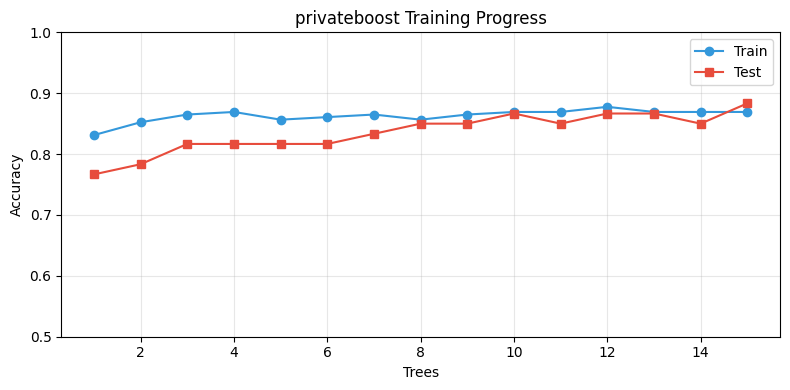


Final: Train=86.92%, Test=88.33%
Best test accuracy: 88.33%


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_TREES+1), train_acc_history, "o-", label="Train", color="#3498db")
ax.plot(range(1, N_TREES+1), test_acc_history, "s-", label="Test", color="#e74c3c")
ax.set_xlabel("Trees")
ax.set_ylabel("Accuracy")
ax.set_title("privateboost Training Progress")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

print(f"\nFinal: Train={train_acc_history[-1]:.2%}, Test={test_acc_history[-1]:.2%}")
print(f"Best test accuracy: {max(test_acc_history):.2%}")

---
# Part 2: Split Quality Analysis

How much accuracy do we lose by finding splits from histogram-binned gradients instead of exact values?

We compare the **gain** achieved by:
- **Optimal**: Exhaustive search over all split points
- **privateboost**: Best split from 10-bin gradient histograms

In [7]:
# Use initial predictions for split analysis
predictions = np.full(len(y_train), aggregator.model.initial_prediction)

def compute_optimal_gain(X, y, preds, feat_idx, lambda_reg=1.0):
    """Find optimal split gain by exhaustive search."""
    g = preds - y
    h = np.ones_like(g)
    total_g, total_h = g.sum(), h.sum()
    base = (total_g ** 2) / (total_h + lambda_reg)
    
    idx = np.argsort(X[:, feat_idx])
    vals, gs, hs = X[idx, feat_idx], g[idx], h[idx]
    
    best = 0
    g_left, h_left = 0, 0
    for i in range(len(vals) - 1):
        g_left += gs[i]
        h_left += hs[i]
        if vals[i] == vals[i+1] or h_left < 0.1 or (total_h - h_left) < 0.1:
            continue
        gain = (g_left**2)/(h_left + lambda_reg) + ((total_g-g_left)**2)/((total_h-h_left) + lambda_reg) - base
        best = max(best, gain)
    return best

def compute_pb_gain(X, y, preds, feat_idx, bins, lambda_reg=1.0):
    """Find split gain using histogram binning."""
    g = preds - y
    h = np.ones_like(g)
    total_g, total_h = g.sum(), h.sum()
    base = (total_g ** 2) / (total_h + lambda_reg)
    
    bin_cfg = bins[feat_idx]
    n_bins = bin_cfg.n_bins + 2
    g_hist, h_hist = np.zeros(n_bins), np.zeros(n_bins)
    
    for i in range(len(X)):
        b = int(np.searchsorted(bin_cfg.edges, X[i, feat_idx], side="right")) - 1
        b = max(0, min(b, n_bins - 1))
        g_hist[b] += g[i]
        h_hist[b] += h[i]
    
    best = 0
    for i in range(n_bins - 1):
        g_left, h_left = g_hist[:i+1].sum(), h_hist[:i+1].sum()
        if h_left < 0.1 or (total_h - h_left) < 0.1:
            continue
        gain = (g_left**2)/(h_left + lambda_reg) + ((total_g-g_left)**2)/((total_h-h_left) + lambda_reg) - base
        best = max(best, gain)
    return best

# Compute for all features
results = []
for i, name in enumerate(FEATURES):
    opt = compute_optimal_gain(X_train, y_train, predictions, i, LAMBDA_REG)
    pb = compute_pb_gain(X_train, y_train, predictions, i, bins, LAMBDA_REG)
    ret = (pb / opt * 100) if opt > 0 else 100
    results.append({'feature': name, 'optimal': opt, 'privateboost': pb, 'retention': ret})

for r in results:
    print(f"{r['feature']:>10}: {r['retention']:5.1f}%")

print(f"\nMean retention: {np.mean([r['retention'] for r in results]):.1f}%")

       age: 100.0%
       sex: 100.0%
        cp: 100.0%
  trestbps:  93.6%
      chol:  99.7%
       fbs: 100.0%
   restecg: 100.0%
   thalach:  92.1%
     exang: 100.0%
   oldpeak:  90.2%
     slope: 100.0%
        ca: 100.0%
      thal: 100.0%

Mean retention: 98.1%


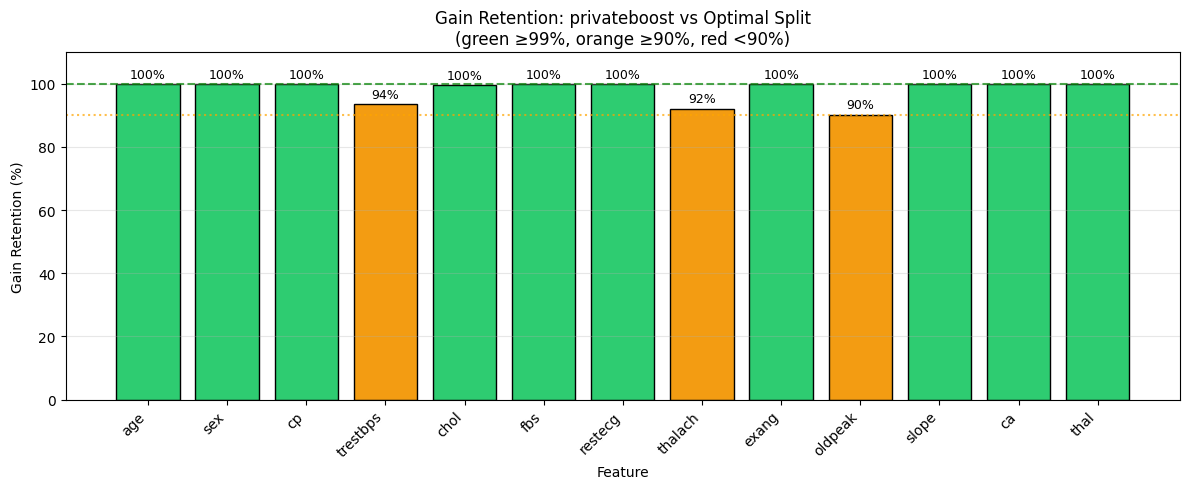

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

features = [r['feature'] for r in results]
retentions = [r['retention'] for r in results]
colors = ['#2ecc71' if r >= 99 else '#f39c12' if r >= 90 else '#e74c3c' for r in retentions]

bars = ax.bar(features, retentions, color=colors, edgecolor='black')
ax.axhline(100, color='green', linestyle='--', alpha=0.7)
ax.axhline(90, color='orange', linestyle=':', alpha=0.7)
ax.set_ylabel('Gain Retention (%)')
ax.set_xlabel('Feature')
ax.set_title('Gain Retention: privateboost vs Optimal Split\n(green ≥99%, orange ≥90%, red <90%)')
ax.set_ylim(0, 110)
plt.xticks(rotation=45, ha='right')
ax.grid(alpha=0.3, axis='y')

for bar, ret in zip(bars, retentions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{ret:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/figures/gain_retention.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: XGBoost Comparison

How does privateboost compare to the XGBoost library?

We compare:
- **privateboost**: Privacy-preserving federated training
- **XGBoost (matched)**: Same hyperparameters for fair comparison
- **XGBoost (default)**: Library defaults as practical baseline

In [9]:
# Use Breast Cancer dataset (larger)
data = load_breast_cancer()
indices = np.random.permutation(len(data.data))
split = int(len(data.data) * 0.8)

X_train_bc = data.data[indices[:split]]
y_train_bc = data.target[indices[:split]]
X_test_bc = data.data[indices[split:]]
y_test_bc = data.target[indices[split:]]

print(f"Breast Cancer: {len(X_train_bc)} train, {len(X_test_bc)} test, {data.data.shape[1]} features")

Breast Cancer: 455 train, 114 test, 30 features


In [ ]:
def train_privateboost_metrics(X_train, y_train, X_test, y_test):
    """Train privateboost and return per-round metrics."""
    shs = [ShareHolder(party_id=i, x_coord=i + 1, min_clients=MIN_CLIENTS) for i in range(N_SHAREHOLDERS)]
    agg = Aggregator(shs, n_bins=N_BINS, threshold=THRESHOLD, min_clients=MIN_CLIENTS, learning_rate=LEARNING_RATE, lambda_reg=LAMBDA_REG)
    clients = [Client(f"c_{i}", X_train[i], float(y_train[i]), shs, threshold=THRESHOLD) for i in range(len(X_train))]
    
    for c in clients: c.submit_stats()
    b = agg.define_bins()
    
    metrics = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
    
    for round_id in range(N_TREES):
        for depth in range(MAX_DEPTH):
            for c in clients: c.submit_gradients(b, agg.model, agg.splits, round_id=round_id, depth=depth, loss="squared")
            if not agg.compute_splits(depth=depth, min_samples=5):
                break
        
        agg.finish_round()
        
        # Metrics
        tr_p = agg.model.predict(X_train)
        te_p = agg.model.predict(X_test)
        
        metrics['train_acc'].append(accuracy_score(y_train, (tr_p >= 0.5).astype(int)))
        metrics['test_acc'].append(accuracy_score(y_test, (te_p >= 0.5).astype(int)))
        metrics['train_loss'].append(log_loss(y_train, np.clip(tr_p, 1e-7, 1-1e-7)))
        metrics['test_loss'].append(log_loss(y_test, np.clip(te_p, 1e-7, 1-1e-7)))
    
    return metrics

def train_xgboost_metrics(X_train, y_train, X_test, y_test, matched=True):
    """Train XGBoost and return per-round metrics."""
    metrics = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
    for n in range(1, N_TREES + 1):
        params = dict(n_estimators=n, max_depth=MAX_DEPTH, learning_rate=LEARNING_RATE, 
                      reg_lambda=LAMBDA_REG, tree_method='hist', max_bin=N_BINS, random_state=42) if matched else dict(n_estimators=n, random_state=42)
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, verbose=False)
        
        metrics['train_acc'].append(accuracy_score(y_train, model.predict(X_train)))
        metrics['test_acc'].append(accuracy_score(y_test, model.predict(X_test)))
        metrics['train_loss'].append(log_loss(y_train, model.predict_proba(X_train)[:, 1]))
        metrics['test_loss'].append(log_loss(y_test, model.predict_proba(X_test)[:, 1]))
    return metrics

print("Training privateboost...")
pb_m = train_privateboost_metrics(X_train_bc, y_train_bc, X_test_bc, y_test_bc)
print("Training XGBoost (matched)...")
xgb_matched = train_xgboost_metrics(X_train_bc, y_train_bc, X_test_bc, y_test_bc, matched=True)
print("Training XGBoost (default)...")
xgb_default = train_xgboost_metrics(X_train_bc, y_train_bc, X_test_bc, y_test_bc, matched=False)
print("Done!")

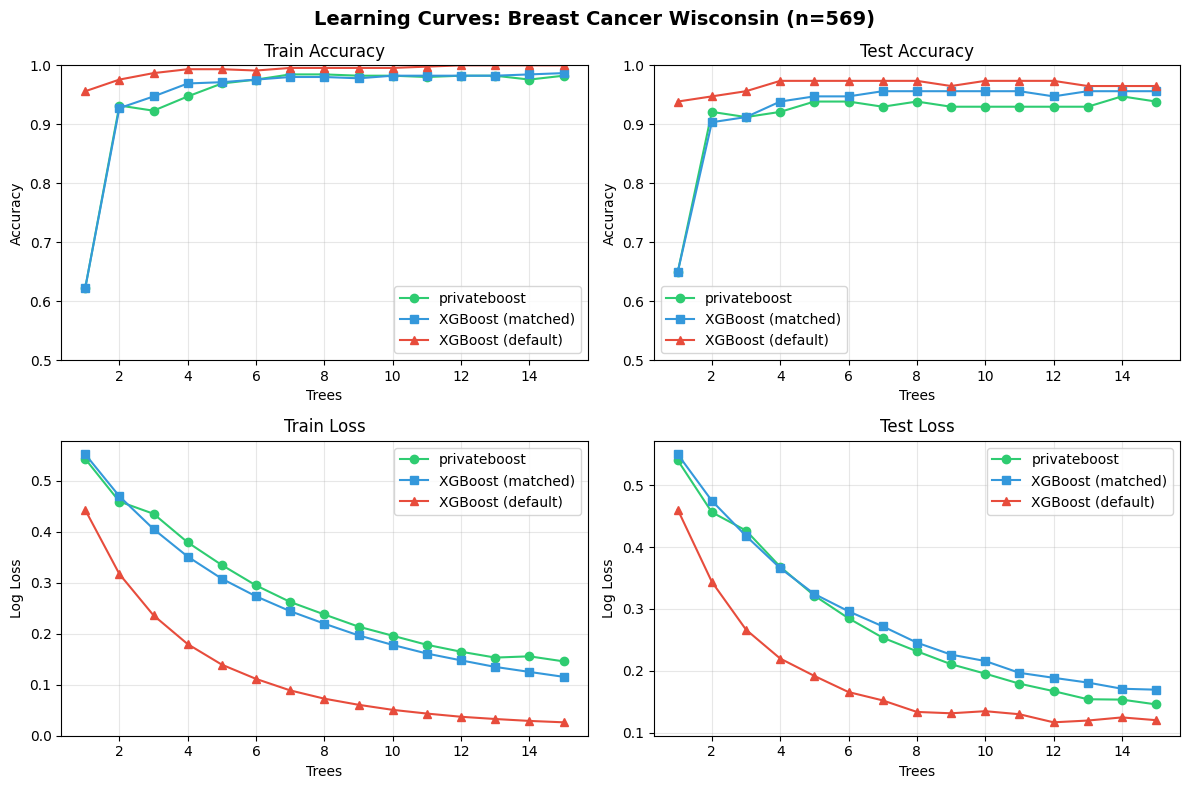


Final Test Accuracy:
  privateboost:      93.86%
  XGBoost (matched): 95.61%
  XGBoost (default): 96.49%


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
trees = range(1, N_TREES + 1)
colors = {'pb': '#2ecc71', 'matched': '#3498db', 'default': '#e74c3c'}

for ax, key, title, ylabel in [
    (axes[0,0], 'train_acc', 'Train Accuracy', 'Accuracy'),
    (axes[0,1], 'test_acc', 'Test Accuracy', 'Accuracy'),
    (axes[1,0], 'train_loss', 'Train Loss', 'Log Loss'),
    (axes[1,1], 'test_loss', 'Test Loss', 'Log Loss'),
]:
    ax.plot(trees, pb_m[key], 'o-', color=colors['pb'], label='privateboost')
    ax.plot(trees, xgb_matched[key], 's-', color=colors['matched'], label='XGBoost (matched)')
    ax.plot(trees, xgb_default[key], '^-', color=colors['default'], label='XGBoost (default)')
    ax.set_xlabel('Trees')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    if 'acc' in key: ax.set_ylim(0.5, 1.0)

fig.suptitle('Learning Curves: Breast Cancer Wisconsin (n=569)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Test Accuracy:")
print(f"  privateboost:      {pb_m['test_acc'][-1]:.2%}")
print(f"  XGBoost (matched): {xgb_matched['test_acc'][-1]:.2%}")
print(f"  XGBoost (default): {xgb_default['test_acc'][-1]:.2%}")

---
# Summary

**Key findings:**
- privateboost achieves **98% mean gain retention** compared to optimal splits (10 of 13 features at 100%)
- Test accuracy is **comparable to standard XGBoost** on both datasets
- **Individual data is never revealed** — only aggregate statistics leave each client

**Security properties (2-of-3 Shamir threshold):**
- Any single shareholder learns nothing about individual values
- Aggregator sees only aggregates, never raw values or client IDs
- Minimum 10 clients required to prevent individual isolation

---
# Part 4: Dropout Resilience

How does the protocol handle client dropout during training?

We simulate three dropout scenarios:
- **Per-round dropout**: At each tree, x% of clients skip the entire round (simulates session disconnects)
- **Per-depth dropout**: At each depth level, x% of clients skip that depth only (simulates transient network issues)
- **Both**: Combines per-round and per-depth dropout (most realistic scenario)

With 237 clients and `min_clients=10`, we can theoretically lose up to ~96% of clients. However, since the aggregator selects shareholders with the best commitment overlap, actual resilience depends on which clients drop.

In [ ]:
def train_with_dropout(X_train, y_train, X_test, y_test, dropout_rate, dropout_mode="per_round", seed=42):
    """Train privateboost with simulated client dropout.
    
    Args:
        dropout_rate: Fraction of clients to drop (0.0 to 1.0)
        dropout_mode: "per_round", "per_depth", or "both"
        seed: Random seed for reproducibility
    
    Returns:
        Final test accuracy, or None if training failed due to insufficient clients
    """
    rng = np.random.default_rng(seed)
    
    shs = [ShareHolder(party_id=i, x_coord=i + 1, min_clients=MIN_CLIENTS) for i in range(N_SHAREHOLDERS)]
    agg = Aggregator(shs, n_bins=N_BINS, threshold=THRESHOLD, min_clients=MIN_CLIENTS, 
                     learning_rate=LEARNING_RATE, lambda_reg=LAMBDA_REG)
    clients = [Client(f"c_{i}", X_train[i], float(y_train[i]), shs, threshold=THRESHOLD) 
               for i in range(len(X_train))]
    
    # All clients participate in stats (bins are computed once at start)
    for c in clients:
        c.submit_stats()
    
    try:
        b = agg.define_bins()
    except ValueError:
        return None  # Not enough clients for stats
    
    try:
        for round_id in range(N_TREES):
            # Per-round dropout: select clients that will participate in this entire round
            if dropout_mode in ("per_round", "both"):
                round_mask = rng.random(len(clients)) >= dropout_rate
                round_clients = [c for c, active in zip(clients, round_mask) if active]
            else:
                round_clients = clients
            
            for depth in range(MAX_DEPTH):
                # Per-depth dropout: additional filtering for this depth
                if dropout_mode in ("per_depth", "both"):
                    depth_mask = rng.random(len(round_clients)) >= dropout_rate
                    active_clients = [c for c, active in zip(round_clients, depth_mask) if active]
                else:
                    active_clients = round_clients
                
                for c in active_clients:
                    c.submit_gradients(b, agg.model, agg.splits, round_id=round_id, depth=depth, loss="squared")
                
                if not agg.compute_splits(depth=depth, min_samples=5):
                    break
            
            agg.finish_round()
    except ValueError:
        return None  # Dropped below min_clients threshold
    
    # Evaluate on test set
    test_preds = agg.model.predict(X_test)
    return accuracy_score(y_test, (test_preds >= 0.5).astype(int))

# Test dropout rates
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
n_trials = 5  # Multiple trials to account for randomness

print("Running dropout simulations...\n")

results = {}
for mode in ["per_round", "per_depth", "both"]:
    results[mode] = {rate: [] for rate in dropout_rates}
    for rate in dropout_rates:
        for trial in range(n_trials):
            acc = train_with_dropout(X_train, y_train, X_test, y_test, rate, mode, seed=42+trial)
            results[mode][rate].append(acc)
        
        successes = [a for a in results[mode][rate] if a is not None]
        if successes:
            print(f"{mode:>10} {rate:3.0%}: {np.mean(successes):.2%} ({len(successes)}/{n_trials} succeeded)")
        else:
            print(f"{mode:>10} {rate:3.0%}: FAILED (all trials below min_clients)")
    print()

print("Done!")

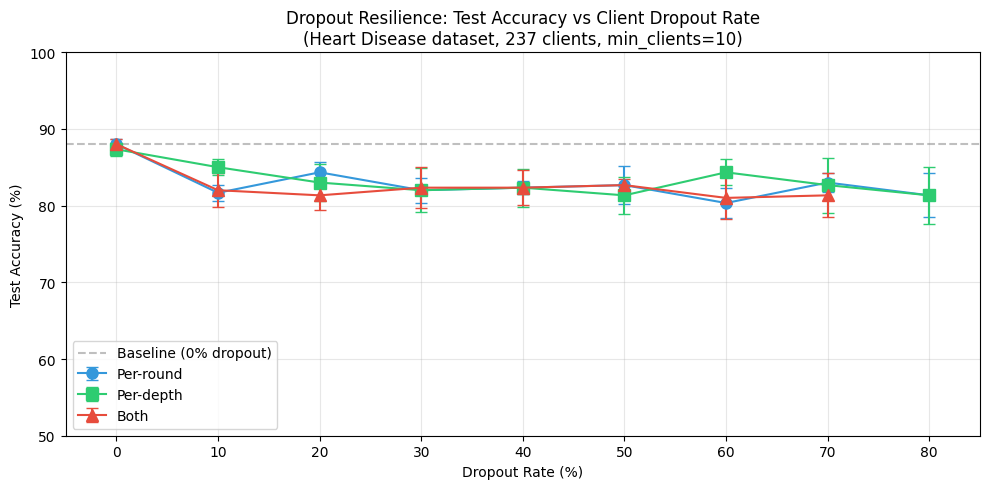


Baseline accuracy (0% dropout): 88.00%

Max dropout maintaining >83% accuracy:
   Per-round: 70%
   Per-depth: 60%
        Both: 0%


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

def summarize_results(mode_results):
    means, stds, success_rates = [], [], []
    for rate in dropout_rates:
        successes = [a for a in mode_results[rate] if a is not None]
        if successes:
            means.append(np.mean(successes))
            stds.append(np.std(successes))
        else:
            means.append(np.nan)
            stds.append(0)
        success_rates.append(len(successes) / n_trials)
    return np.array(means), np.array(stds), np.array(success_rates)

x = np.array(dropout_rates) * 100
colors = {'per_round': '#3498db', 'per_depth': '#2ecc71', 'both': '#e74c3c'}
labels = {'per_round': 'Per-round', 'per_depth': 'Per-depth', 'both': 'Both'}
markers = {'per_round': 'o', 'per_depth': 's', 'both': '^'}

for mode in ["per_round", "per_depth", "both"]:
    means, stds, success = summarize_results(results[mode])
    ax.errorbar(x, means * 100, yerr=stds * 100, fmt=f'{markers[mode]}-', color=colors[mode], 
                label=labels[mode], capsize=4, markersize=8)

# Add baseline (0% dropout)
baseline = summarize_results(results["per_round"])[0][0]
ax.axhline(baseline * 100, color='gray', linestyle='--', alpha=0.5, label='Baseline (0% dropout)')

ax.set_xlabel('Dropout Rate (%)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Dropout Resilience: Test Accuracy vs Client Dropout Rate\n(Heart Disease dataset, 237 clients, min_clients=10)')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(-5, 85)
ax.set_ylim(50, 100)

plt.tight_layout()
plt.savefig('../docs/figures/dropout_resilience.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print(f"\nBaseline accuracy (0% dropout): {baseline:.2%}")
print(f"\nMax dropout maintaining >{baseline-0.05:.0%} accuracy:")
for mode in ["per_round", "per_depth", "both"]:
    means = summarize_results(results[mode])[0]
    stable = [r for r, m in zip(dropout_rates, means) if not np.isnan(m) and m >= baseline - 0.05]
    if stable:
        print(f"  {labels[mode]:>10}: {max(stable):.0%}")
    else:
        print(f"  {labels[mode]:>10}: 0% (degrades immediately)")